<a href="https://colab.research.google.com/github/NyssaRomana/IDCamp-Dicoding/blob/main/duasembilanmaret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install google-play-scraper

In [ ]:
# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews, Sort, reviews_all

In [ ]:
import pandas as pd # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None # Menonaktifkan peringatan chaining
import numpy as np # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed) # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt # Matplotlib untuk visualisasi data
import seaborn as sns # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

import datetime as dt # Manipulasi data waktu dan tanggal
import re # Modul untuk bekerja dengan ekspresi reguler
import string # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize # Tokenisasi teks
from nltk.corpus import stopwords # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt') # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('punkt_tab')
nltk.download('stopwords') # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews_all, Sort

# Mengambil semua ulasan dari aplikasi dengan ID 'com.byu.id' di Google Play Store.
# Proses scraping mungkin memerlukan beberapa saat tergantung pada jumlah ulasan yang ada.
scrapreview = reviews_all(
    'com.shopee.id',           # ID aplikasi
    lang='id',              # Bahasa ulasan (default: 'en')
    country='id',           # Negara (default: 'us')
    sort=Sort.MOST_RELEVANT, # Urutan ulasan (default: Sort.MOST_RELEVANT)
    count=1000              # Jumlah maksimum ulasan yang ingin diambil
)

In [ ]:
# Menyimpan ulasan dalam file CSV
import csv

with open('ulasan_app_shopee.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Review'])  # Menulis header kolom
    for review in scrapreview:
        writer.writerow([review['content']])  # Menulis konten ulasan ke dalam file CSV

In [ ]:
app_reviews_df = pd.DataFrame(scrapreview)
app_reviews_df.shape
app_reviews_df.head()
app_reviews_df.to_csv('ulasan_app_shopee.csv', index=False)

# Membuat DataFrame dari hasil scrapreview
app_reviews_df = pd.DataFrame(scrapreview)

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

In [ ]:
# Menampilkan lima baris pertama dari DataFrame app_reviews_df
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,efe1d2ea-d52a-4018-bc64-871971ef8f6f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"padahal saya pelanggan setia shopee,tapi setel...",1,2,3.70.24,2026-03-25 04:54:07,"Hai kak Fens Iryanto, maaf ya udah buat risau ...",2026-03-24 10:23:17,3.70.24
1,9ca76e21-8ef2-4ce3-8eb0-090ecaf1d422,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasinya bagus, buat pesan beli barang pun ...",3,3,3.69.35,2026-03-17 22:12:47,"Hai kak Ardhyka Akasia, maaf banget buat kamu ...",2026-03-18 00:29:23,3.69.35
2,da22d3da-e263-4fa8-b59d-38262937daa2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sebagai customer yang udah belanja puluhan s.d...,1,1,3.70.26,2026-03-27 21:51:26,"Hi kak Maulana Ae, maaf bikin ga nyaman terkai...",2026-03-27 22:12:04,3.70.26
3,4af11c18-5a9a-4bb3-9034-bcf52578cb14,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,APLIKASI IKLAN TERMAKSA. lagi buka apk apa tib...,2,1,3.70.26,2026-03-28 03:23:21,None,NaT,3.70.26
4,73cbf1f9-1b5b-481e-ac67-7332f555cb73,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sangat kecewa dengan layanan Shopee. Saya meng...,1,2,3.69.36,2026-03-23 15:39:08,"Hai kak Firza, mohon maaf atas ketidaknyamanan...",2026-03-23 17:08:39,3.69.36


In [ ]:
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225000 entries, 0 to 224999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              225000 non-null  object        
 1   userName              225000 non-null  object        
 2   userImage             225000 non-null  object        
 3   content               225000 non-null  object        
 4   score                 225000 non-null  int64         
 5   thumbsUpCount         225000 non-null  int64         
 6   reviewCreatedVersion  184316 non-null  object        
 7   at                    225000 non-null  datetime64[ns]
 8   replyContent          148754 non-null  object        
 9   repliedAt             148754 non-null  datetime64[ns]
 10  appVersion            184316 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 18.9+ MB


In [ ]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = app_reviews_df.dropna()

In [ ]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 123030 entries, 0 to 224998
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              123030 non-null  object        
 1   userName              123030 non-null  object        
 2   userImage             123030 non-null  object        
 3   content               123030 non-null  object        
 4   score                 123030 non-null  int64         
 5   thumbsUpCount         123030 non-null  int64         
 6   reviewCreatedVersion  123030 non-null  object        
 7   at                    123030 non-null  datetime64[ns]
 8   replyContent          123030 non-null  object        
 9   repliedAt             123030 non-null  datetime64[ns]
 10  appVersion            123030 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 11.3+ MB


# **Preprocessing**

In [ ]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [ ]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [ ]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [ ]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,efe1d2ea-d52a-4018-bc64-871971ef8f6f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"padahal saya pelanggan setia shopee,tapi setel...",1,2,3.70.24,2026-03-25 04:54:07,"Hai kak Fens Iryanto, maaf ya udah buat risau ...",2026-03-24 10:23:17,3.70.24,padahal saya pelanggan setia shopeetapi setela...,padahal saya pelanggan setia shopeetapi setela...,padahal saya pelanggan setia shopeetapi setela...,"[padahal, saya, pelanggan, setia, shopeetapi, ...","[pelanggan, setia, shopeetapi, cek, pesanan, n...",pelanggan setia shopeetapi cek pesanan nunggu ...
1,9ca76e21-8ef2-4ce3-8eb0-090ecaf1d422,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasinya bagus, buat pesan beli barang pun ...",3,3,3.69.35,2026-03-17 22:12:47,"Hai kak Ardhyka Akasia, maaf banget buat kamu ...",2026-03-18 00:29:23,3.69.35,Aplikasinya bagus buat pesan beli barang pun o...,aplikasinya bagus buat pesan beli barang pun o...,aplikasinya bagus buat pesan beli barang pun o...,"[aplikasinya, bagus, buat, pesan, beli, barang...","[aplikasinya, bagus, pesan, beli, barang, oke,...",aplikasinya bagus pesan beli barang oke bintan...
2,da22d3da-e263-4fa8-b59d-38262937daa2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sebagai customer yang udah belanja puluhan s.d...,1,1,3.70.26,2026-03-27 21:51:26,"Hi kak Maulana Ae, maaf bikin ga nyaman terkai...",2026-03-27 22:12:04,3.70.26,Sebagai customer yang udah belanja puluhan sd ...,sebagai customer yang udah belanja puluhan sd ...,sebagai customer yang sudah belanja puluhan sd...,"[sebagai, customer, yang, sudah, belanja, pulu...","[customer, belanja, puluhan, sd, ratus, juta, ...",customer belanja puluhan sd ratus juta kecewa ...
4,73cbf1f9-1b5b-481e-ac67-7332f555cb73,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sangat kecewa dengan layanan Shopee. Saya meng...,1,2,3.69.36,2026-03-23 15:39:08,"Hai kak Firza, mohon maaf atas ketidaknyamanan...",2026-03-23 17:08:39,3.69.36,Sangat kecewa dengan layanan Shopee Saya menga...,sangat kecewa dengan layanan shopee saya menga...,sangat kecewa dengan layanan shopee saya menga...,"[sangat, kecewa, dengan, layanan, shopee, saya...","[kecewa, layanan, shopee, mengalami, kejadian,...",kecewa layanan shopee mengalami kejadian merug...
5,0bb14ae7-1fc9-482c-88d4-941b85f36124,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tolong tambahkan di pengaturan opsi untuk mema...,1,1,3.69.36,2026-03-28 01:04:07,Hai kak Aflah Zaidan mohon maaf atas ketidakny...,2026-03-28 02:09:22,3.69.36,Tolong tambahkan di pengaturan opsi untuk mema...,tolong tambahkan di pengaturan opsi untuk mema...,tolong tambahkan di pengaturan opsi untuk mema...,"[tolong, tambahkan, di, pengaturan, opsi, untu...","[tolong, tambahkan, pengaturan, opsi, mematika...",tolong tambahkan pengaturan opsi mematikan vid...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224990,ef3d4d8b-bbd9-45cb-82ce-e712db027686,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Duh mau pencet produk kok malah layar putih do...,3,0,2.95.52,2022-12-24 17:07:55,"hai kak, wah makasih ya bintang 5 dan feedback...",2022-08-03 10:09:20,2.95.52,Duh mau pencet produk kok malah layar putih do...,duh mau pencet produk kok malah layar putih do...,aduh mau pencet produk kok bahkan layar putih ...,"[aduh, mau, pencet, produk, kok, bahkan, layar...","[aduh, pencet, produk, layar, putih, doang, up...",aduh pencet produk layar putih doang update ra...
224991,1140a208-d94f-4ae3-a56d-dc6a000cecaf,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Selalu puas belanja di shopee , pngiriman cepa...",5,0,2.60.12,2020-10-10 16:24:26,"Waaaah thanks yah kak Astri, mimin seneng bang...",2020-10-10 17:27:51,2.60.12,Selalu puas b

In [ ]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [ ]:
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:

    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score > 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif (score < 0):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif
    else:
        polarity = 'neutral'
        # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [ ]:
clean_df[['polarity_score', 'polarity']] = clean_df['text_stopword'].apply(
    lambda x: pd.Series(sentiment_analysis_lexicon_indonesia(x))
)

print("Distribusi Sentimen:")
print(clean_df['polarity'].value_counts())

clean_df[['text_stopword', 'polarity_score', 'polarity']].head()

Distribusi Sentimen:
polarity
positive    59756
negative    55307
neutral      7967
Name: count, dtype: int64


,text_stopword,polarity_score,polarity
0,"[pelanggan, setia, shopeetapi, cek, pesanan, n...",5,positive
1,"[aplikasinya, bagus, pesan, beli, barang, oke,...",-37,negative
2,"[customer, belanja, puluhan, sd, ratus, juta, ...",-1,negative
4,"[kecewa, layanan, shopee, mengalami, kejadian,...",-10,negative
5,"[tolong, tambahkan, pengaturan, opsi, mematika...",10,positive


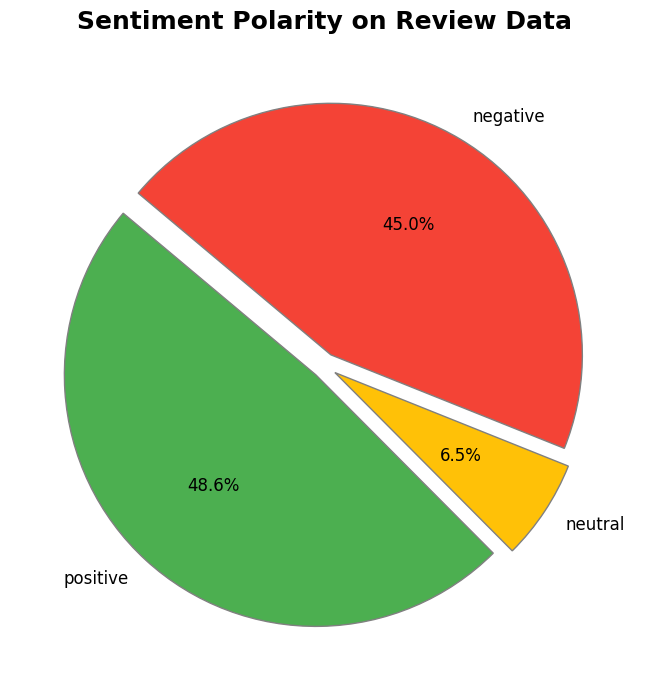

In [ ]:
import matplotlib.pyplot as plt

# Hitung jumlah tiap kelas
sentiment_counts = clean_df['polarity'].value_counts()

labels = ['positive', 'neutral', 'negative']
sizes = [sentiment_counts.get(label, 0) for label in labels]

# Semua slice sedikit dipisahkan
explode = (0.05, 0.05, 0.05)

colors = ['#4CAF50', '#FFC107', '#F44336']  # hijau, kuning, merah

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    colors=colors,
    wedgeprops={'edgecolor': 'grey', 'linewidth': 1},
    textprops={'fontsize': 12}
)

# Perbesar font persentase
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color('black')

ax.set_title('Sentiment Polarity on Review Data', fontsize=18, pad=16, weight='bold')

plt.tight_layout()
plt.show()

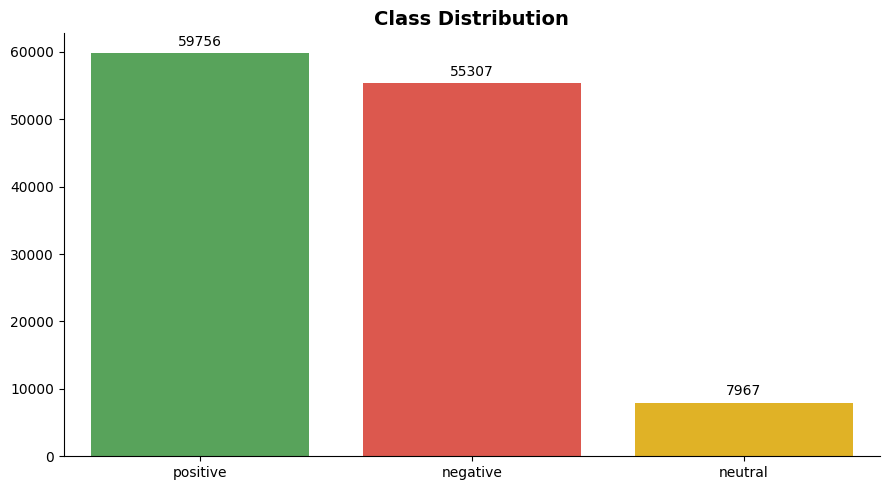

In [ ]:
# Grafik Batang

# Urutkan dari terbesar ke kecil
order = clean_df['polarity'].value_counts().index

palette = {
    'positive': '#4CAF50',
    'neutral': '#FFC107',
    'negative': '#F44336'
}

plt.figure(figsize=(9, 5))

ax = sns.countplot(
    x='polarity',
    data=clean_df,
    order=order,
    hue='polarity',
    palette=palette,
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10,
                xytext=(0, 3),
                textcoords='offset points')

# Judul lebih simple
ax.set_title('Class Distribution', fontsize=14, weight='bold')


ax.set_xlabel('')
ax.set_ylabel('')

sns.despine()
plt.tight_layout()
plt.show()

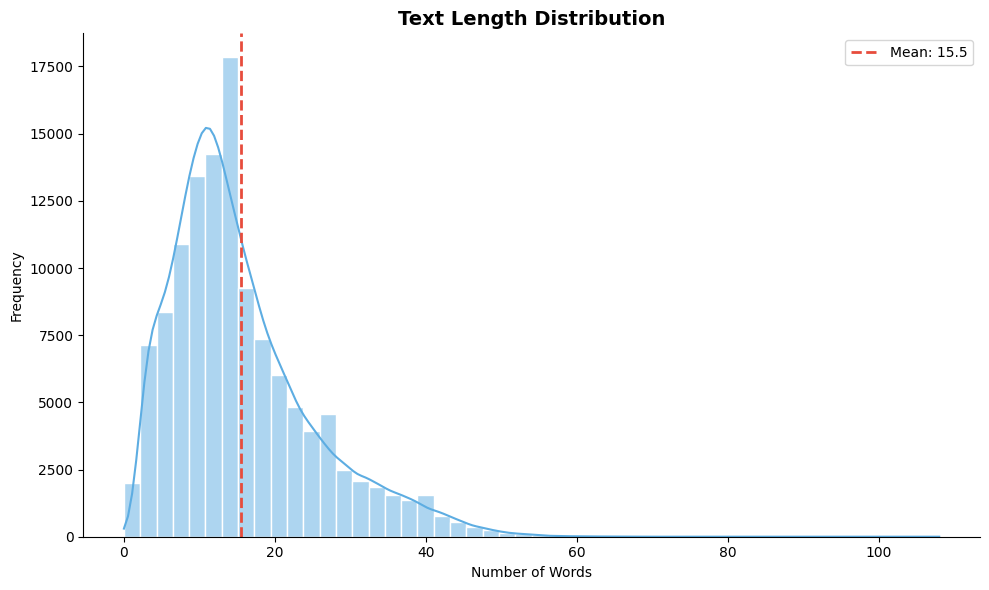

In [ ]:
plt.figure(figsize=(10, 6))

# Hitung panjang teks
clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))

main_color = '#5DADE2'

sns.histplot(
    clean_df['text_length'],
    bins=50,
    kde=True,
    color=main_color,
    edgecolor='white'
)

# Garis mean (warna kontras)
mean_length = clean_df['text_length'].mean()
plt.axvline(mean_length, color='#E74C3C', linestyle='--', linewidth=2,
            label=f'Mean: {mean_length:.1f}')

plt.title('Text Length Distribution', fontsize=14, weight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

Mayoritas ulasan memiliki panjang sekitar 10–20 kata, dengan distribusi miring ke kanan (right-skewed), menunjukkan adanya beberapa ulasan panjang namun jumlahnya sedikit

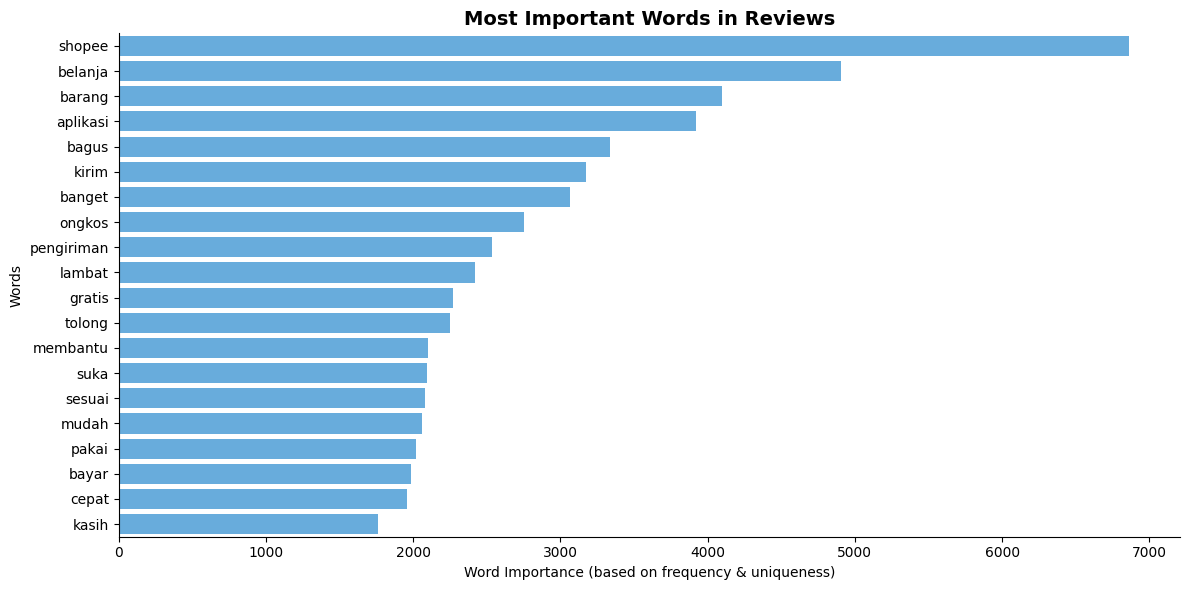

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='score',
    y='word',
    data=tfidf_df,
    color='#54AFF0'
)

plt.title('Most Important Words in Reviews', fontsize=14, weight='bold')
plt.xlabel('Word Importance (based on frequency & uniqueness)')
plt.ylabel('Words')

sns.despine()
plt.tight_layout()
plt.show()

In [74]:
clean_df.head(2)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,text_length
0,efe1d2ea-d52a-4018-bc64-871971ef8f6f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"padahal saya pelanggan setia shopee,tapi setel...",1,2,3.70.24,2026-03-25 04:54:07,"Hai kak Fens Iryanto, maaf ya udah buat risau ...",2026-03-24 10:23:17,3.70.24,padahal saya pelanggan setia shopeetapi setela...,padahal saya pelanggan setia shopeetapi setela...,padahal saya pelanggan setia shopeetapi setela...,"[padahal, saya, pelanggan, setia, shopeetapi, ...","[pelanggan, setia, shopeetapi, cek, pesanan, n...",pelanggan setia shopeetapi cek pesanan nunggu ...,5,positive,34
1,9ca76e21-8ef2-4ce3-8eb0-090ecaf1d422,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasinya bagus, buat pesan beli barang pun ...",3,3,3.69.35,2026-03-17 22:12:47,"Hai kak Ardhyka Akasia, maaf banget buat kamu ...",2026-03-18 00:29:23,3.69.35,Aplikasinya bagus buat pesan beli barang pun o...,aplikasinya bagus buat pesan beli barang pun o...,aplikasinya bagus buat pesan beli barang pun o...,"[aplikasinya, bagus, buat, pesan, beli, barang...","[aplikasinya, bagus, pesan, beli, barang, oke,...",aplikasinya bagus pesan beli barang oke bintan...,-37,negative,39


In [116]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

clean_df = clean_df[clean_df['text_akhir'].str.len() > 5]

# Fitur & label
X = clean_df['text_akhir']
y = clean_df['polarity']

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)
X_tfidf = tfidf.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

print("TF-IDF Shape:", X_tfidf.shape)
print("Jumlah fitur:", len(tfidf.get_feature_names_out()))
print("Contoh fitur:", tfidf.get_feature_names_out()[:10])

TF-IDF Shape: (122951, 7000)
Jumlah fitur: 7000
Contoh fitur: ['aamiin' 'abal' 'abal abal' 'abang' 'acak' 'acara' 'accord' 'account'
 'aceh' 'adaa']


In [117]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

best_score = 0
best_c = None
best_model = None

# 🔍 Cari C terbaik
for c in [0.6, 0.7, 0.8, 0.9]:
    model = LinearSVC(
        C=c,
        class_weight={
            'positive': 1,
            'negative': 1,
            'neutral': 2
        },
        max_iter=2000
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"C={c} → Accuracy: {acc:.4f}")

    if acc > best_score:
        best_score = acc
        best_c = c
        best_model = model


# 🎯 Model terbaik
print("\nBest C:", best_c)
print("Best Accuracy:", best_score)

# 🔥 Evaluasi final
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

print("\nSVM - accuracy_train:", accuracy_score(y_train, y_pred_train))
print("SVM - accuracy_test:", accuracy_score(y_test, y_pred_test))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test))

C=0.6 → Accuracy: 0.9124
C=0.7 → Accuracy: 0.9127
C=0.8 → Accuracy: 0.9127
C=0.9 → Accuracy: 0.9129

Best C: 0.9
Best Accuracy: 0.9128542962872596

SVM - accuracy_train: 0.9420902806018707
SVM - accuracy_test: 0.9128542962872596

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.91      0.96      0.94     11062
     neutral       0.65      0.21      0.32      1590
    positive       0.92      0.96      0.94     11939

    accuracy                           0.91     24591
   macro avg       0.83      0.71      0.73     24591
weighted avg       0.90      0.91      0.90     24591



In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Model Logistic Regression
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')

# Training
logreg.fit(X_train, y_train)

# Prediksi TRAIN
y_pred_train_lr = logreg.predict(X_train)

# Prediksi TEST
y_pred_test_lr = logreg.predict(X_test)

# Accuracy
print("Logistic Regression - accuracy_train:", accuracy_score(y_train, y_pred_train_lr))
print("Logistic Regression - accuracy_test:", accuracy_score(y_test, y_pred_test_lr))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test_lr))

Logistic Regression - accuracy_train: 0.8763521756811712
Logistic Regression - accuracy_test: 0.8364442275629296

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.94      0.85      0.89     11062
     neutral       0.26      0.63      0.37      1590
    positive       0.95      0.85      0.90     11939

    accuracy                           0.84     24591
   macro avg       0.72      0.78      0.72     24591
weighted avg       0.90      0.84      0.86     24591



In [119]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model RF (dibatasi biar tidak berat)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)

# Training
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

# Evaluasi
print("RF - accuracy_train:", accuracy_score(y_train, y_pred_train_rf))
print("RF - accuracy_test:", accuracy_score(y_test, y_pred_test_rf))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test_rf))

RF - accuracy_train: 0.7698149654331029
RF - accuracy_test: 0.7455166524338173

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.70      0.84      0.77     11062
     neutral       0.00      0.00      0.00      1590
    positive       0.80      0.76      0.78     11939

    accuracy                           0.75     24591
   macro avg       0.50      0.53      0.51     24591
weighted avg       0.70      0.75      0.72     24591



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
